# 03. Treinamento e Comparação dos Modelos

**TCC — Modelo de Expected Goals com Aprendizado de Máquina**

Autor: Paulo Gustavo Angelo de Barros

Treinamento e comparação de Regressão Logística, Random Forest e XGBoost, seguindo a metodologia documentada no `CLAUDE.md`:
- **Treino:** Copa 2018, com validação cruzada K-Fold (K=5) para tuning de hiperparâmetros.
- **Teste principal:** Copa 2022 (generalização temporal).
- **Teste externo:** Euro 2020 (generalização entre torneios diferentes).
- **Métricas:** AUC-ROC, Log-Loss, Brier Score.

## 1. Importações

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

from src.models import (
    COMPETICOES,
    TREINO,
    TESTE_PRINCIPAL,
    TESTE_EXTERNO,
    carregar_dataset,
    selecionar_features_comuns,
    preparar_X_y,
    treinar_regressao_logistica,
    treinar_random_forest,
    treinar_xgboost,
    avaliar_holdout,
)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Carregando dados e selecionando features comuns

Reaproveitamos exatamente a lógica de `src/models.py` para não duplicar a definição das features usadas na modelagem.

In [2]:
dfs = {nome: carregar_dataset(nome) for nome in COMPETICOES}
colunas_features = selecionar_features_comuns(dfs)
print(f"{len(colunas_features)} features comuns às três competições:")
print(colunas_features)

X_train, y_train = preparar_X_y(dfs[TREINO], colunas_features)
X_teste_principal, y_teste_principal = preparar_X_y(dfs[TESTE_PRINCIPAL], colunas_features)
X_teste_externo, y_teste_externo = preparar_X_y(dfs[TESTE_EXTERNO], colunas_features)

print(f"\nTreino (Copa 2018): {X_train.shape}")
print(f"Teste principal (Copa 2022): {X_teste_principal.shape}")
print(f"Teste externo (Euro 2020): {X_teste_externo.shape}")

29 features comuns às três competições:
['angulo_gol', 'distancia_gol', 'minute', 'period', 'play_pattern_From Corner', 'play_pattern_From Counter', 'play_pattern_From Free Kick', 'play_pattern_From Goal Kick', 'play_pattern_From Keeper', 'play_pattern_From Kick Off', 'play_pattern_From Throw In', 'play_pattern_Other', 'play_pattern_Regular Play', 'shot_body_part_Head', 'shot_body_part_Left Foot', 'shot_body_part_Other', 'shot_body_part_Right Foot', 'shot_technique_Backheel', 'shot_technique_Diving Header', 'shot_technique_Half Volley', 'shot_technique_Lob', 'shot_technique_Normal', 'shot_technique_Overhead Kick', 'shot_technique_Volley', 'shot_type_Free Kick', 'shot_type_Open Play', 'under_pressure', 'x', 'y']

Treino (Copa 2018): (1638, 29)
Teste principal (Copa 2022): (1430, 29)
Teste externo (Euro 2020): (1234, 29)


## 3. Treinamento dos três modelos

O treinamento roda o mesmo pipeline usado em `python src/models.py` (o script também salva os modelos em `results/models/` e a tabela comparativa em `results/tabela_comparativa_modelos.csv`).

In [3]:
modelo_lr = treinar_regressao_logistica(X_train, y_train)
modelo_rf = treinar_random_forest(X_train, y_train)
modelo_xgb = treinar_xgboost(X_train, y_train)

modelos = {
    "Regressão Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "XGBoost": modelo_xgb,
}

    Melhores parâmetros (RF): {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 200} | AUC-ROC (CV): 0.7432


    Melhores parâmetros (XGB): {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100} | AUC-ROC (CV): 0.7158


## 4. Tabela comparativa de métricas

Carregamos a tabela já gerada por `src/models.py` (inclui a métrica de treino via validação cruzada out-of-fold, mais honesta que avaliar no próprio conjunto de treino).

In [4]:
tabela_resultados = pd.read_csv(Path.cwd().parent / "results" / "tabela_comparativa_modelos.csv")
tabela_resultados

,modelo,conjunto,auc_roc,log_loss,brier_score
0,regressao_logistica,treino_2018_cv,0.7511,0.2529,0.0689
1,regressao_logistica,teste_principal_2022,0.7141,0.3265,0.0867
2,regressao_logistica,teste_externo_euro2020,0.7315,0.2950,0.0798
3,random_forest,treino_2018_cv,0.7398,0.2513,0.0687
4,random_forest,teste_principal_2022,0.7669,0.2974,0.0860
5,random_forest,teste_externo_euro2020,0.7508,0.2845,0.0806
6,xgboost,treino_2018_cv,0.7134,0.2586,0.0699
7,xgboost,teste_principal_2022,0.7464,0.3036,0.0870
8,xgboost,teste_externo_euro2020,0.7482,0.2847,0.0805


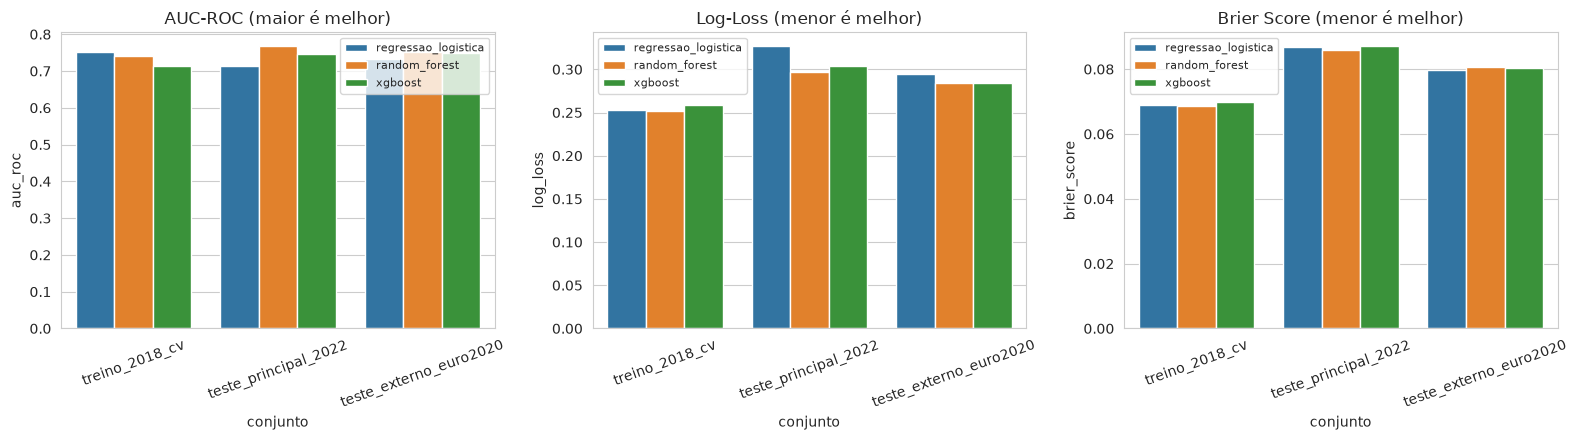

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metricas = ["auc_roc", "log_loss", "brier_score"]
titulos = ["AUC-ROC (maior é melhor)", "Log-Loss (menor é melhor)", "Brier Score (menor é melhor)"]

for ax, metrica, titulo in zip(axes, metricas, titulos):
    sns.barplot(data=tabela_resultados, x="conjunto", y=metrica, hue="modelo", ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Curvas ROC nos conjuntos de teste

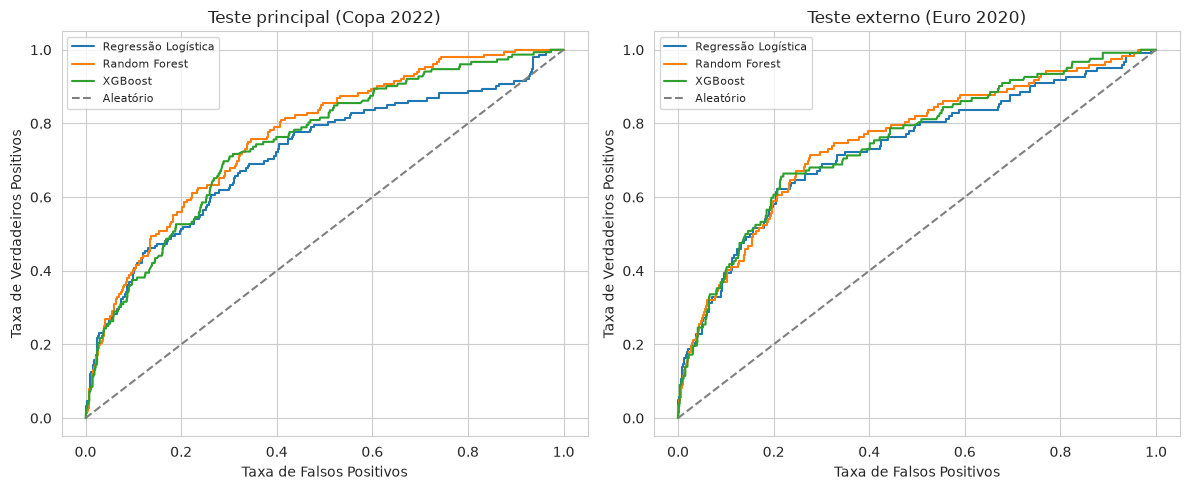

In [6]:
conjuntos_teste = {
    "Teste principal (Copa 2022)": (X_teste_principal, y_teste_principal),
    "Teste externo (Euro 2020)": (X_teste_externo, y_teste_externo),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (titulo, (X_teste, y_teste)) in zip(axes, conjuntos_teste.items()):
    for nome_modelo, modelo in modelos.items():
        proba = modelo.predict_proba(X_teste)[:, 1]
        fpr, tpr, _ = roc_curve(y_teste, proba)
        ax.plot(fpr, tpr, label=nome_modelo)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
    ax.set_title(titulo)
    ax.set_xlabel("Taxa de Falsos Positivos")
    ax.set_ylabel("Taxa de Verdadeiros Positivos")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Importância das features (Random Forest e XGBoost)

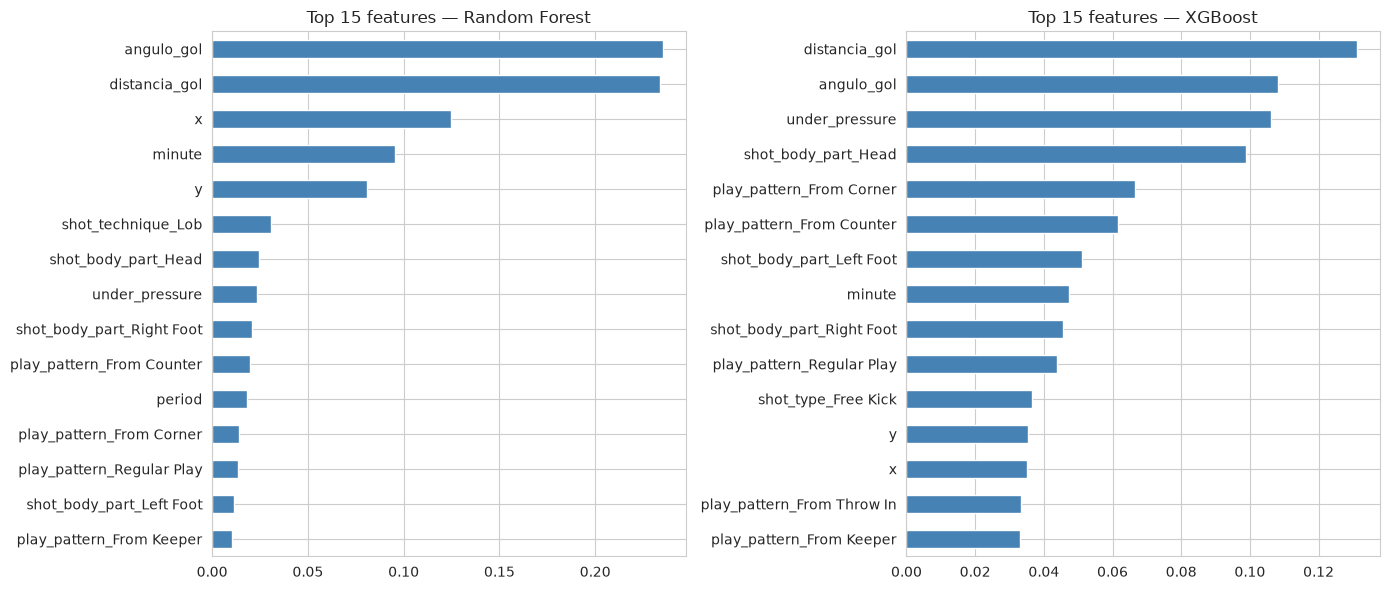

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (nome_modelo, modelo) in zip(axes, [("Random Forest", modelo_rf), ("XGBoost", modelo_xgb)]):
    importancias = pd.Series(modelo.feature_importances_, index=colunas_features)
    importancias = importancias.sort_values(ascending=True).tail(15)
    importancias.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Top 15 features — {nome_modelo}")

plt.tight_layout()
plt.show()

## 7. Discussão e próximos passos

- Os três modelos convergem para `distancia_gol` e `angulo_gol` como as features mais importantes, coerente com a literatura de xG.
- A comparação entre teste principal (Copa 2022) e teste externo (Euro 2020) permite avaliar tanto a generalização temporal quanto entre torneios diferentes.
- O modelo campeão (melhor AUC-ROC/Log-Loss/Brier no teste externo) deve ser escolhido para a etapa de interpretabilidade com SHAP (`04_analise_shap.ipynb`) e integração ao dashboard Streamlit.